# HR Employee Performance & Training Analysis
## Comprehensive Data Cleaning, Exploratory Data Analysis (EDA), and Advanced Visualizations
This notebook implements an end-to-end data science workflow on a raw HR Dataset. Our primary objectives are:
1. **Data Cleansing & Preprocessing**: Correct data types, handle missing values, and deduplicate records to ensure statistical integrity.
2. **Exploratory Data Analysis (EDA)**: Profile key business variables, compute organizational KPIs, and examine structural distributions.
3. **Data Visualization**: Construct highly polished, publication-grade visualization charts to present business insights.
4. **Statistical Insights**: Calculate correlation coefficients and retrieve specific outliers to guide strategic business decisions.

<a href="https://colab.research.google.com/github/Ali-Khamis45/orangelab1/blob/main/taskLAB1orange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup and Environment Initialization
We begin the workflow by importing the standard Python data science stack. These tools will handle data loading, manipulation, and high-fidelity statistical visualization:
* **Pandas (`pd`)**: The primary library for tabular data structures and data frames.
* **NumPy (`np`)**: Used for highly efficient numerical array computations and mathematical operations.
* **Matplotlib (`plt`)**: The foundation plotting engine used for canvas rendering.
* **Seaborn (`sns`)**: A high-level declarative statistical plotting package built on top of Matplotlib, enabling rich visual styles and themes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 2. Loading the Raw HR Dataset
We load the source dataset `HR_Dataset.csv` from the local environment into a Pandas DataFrame (`df`). We then execute a preview of the first five records (`df.head()`) to understand the format, column names, and initial values.

In [2]:
df=pd.read_csv('/content/HR_Dataset.csv')
df.head()

,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,0,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,1,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,2,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,4,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


### 3. Dimensionality Assessment
We check the size and dimensions of the dataset using `df.shape`. This returns a tuple representing the total number of records (rows) and attributes (columns) present in the raw data.

In [3]:
df.shape

(3150, 39)

### 4. Listing Column Attributes
We extract the column labels of the dataset using `df.columns` to map out the names of all variables, helping us understand the data dimensions available for analysis.

In [4]:
df.columns

Index(['Unnamed: 0', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'TerminationType', 'TerminationDescription', 'DepartmentType',
       'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode',
       'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score',
       'Current Employee Rating', 'Employee ID', 'Survey Date',
       'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score',
       'Training Date', 'Training Program Name', 'Training Type',
       'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)',
       'Training Cost'],
      dtype='str')

### 5. Profiling Data Types
We audit the data types (`df.dtypes`) of all columns to inspect how the variables have been read (e.g., objects, floats, or integers). Identifying these types is crucial for data type casting, especially for dates or categories.

In [5]:
df.dtypes

Unnamed: 0                      int64
FirstName                         str
LastName                          str
StartDate                         str
ExitDate                          str
Title                             str
Supervisor                        str
ADEmail                           str
BusinessUnit                      str
EmployeeStatus                    str
EmployeeType                      str
PayZone                           str
EmployeeClassificationType        str
TerminationType                   str
TerminationDescription            str
DepartmentType                    str
Division                          str
DOB                               str
State                             str
JobFunctionDescription            str
GenderCode                        str
LocationCode                    int64
RaceDesc                          str
MaritalDesc                       str
Performance Score                 str
Current Employee Rating         int64
Employee ID 

### 6. Descriptive Summary Statistics
We generate general summary statistics for the numerical attributes in the dataset using `df.describe()`. This output yields critical statistical metrics including:
* **Central Tendency**: Mean and median (50% quartile).
* **Dispersion**: Standard deviation (std), minimum (min), maximum (max), and interquartile range (IQR).

In [6]:
df.describe()

,Unnamed: 0,LocationCode,Current Employee Rating,Employee ID,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,1495.748254,45155.332698,2.968254,2502.748254,2.943492,3.021270,2.992381,2.971746,560.525889
std,867.007861,30019.418852,1.020717,866.241991,1.430727,1.407413,1.409244,1.415390,262.485994
min,0.000000,1013.000000,1.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,100.040000
25%,746.000000,17616.500000,2.000000,1750.250000,2.000000,2.000000,2.000000,2.000000,331.475000
50%,1495.500000,44455.500000,3.000000,2504.500000,3.000000,3.000000,3.000000,3.000000,574.300000
75%,2246.750000,71713.250000,3.000000,3254.750000,4.000000,4.000000,4.000000,4.000000,788.070000
max,2999.000000,98052.000000,5.000000,4000.000000,5.000000,5.000000,5.000000,5.000000,999.970000


### 7. Initial Duplicity Audit
Before cleaning, we check for duplicate rows in the raw dataset using `df.duplicated().sum()`. Identifying duplicate records is necessary to prevent double-counting and data skewing.

In [7]:
df.duplicated().sum()

np.int64(150)

### 8. Date Parsing & Missing Values Profiling
We standardize string-based date columns into standard datetime objects to allow time-series manipulation. The columns targeted are:
* `StartDate`
* `ExitDate`
* `DOB`
* `Survey Date`
* `Training Date`

Following parsing, we run a null check (`df.isna().sum()`) to identify missing values across all columns.

In [8]:
df['StartDate'] = pd.to_datetime(df['StartDate'], format='%d-%b-%y', errors='coerce')
df['ExitDate'] = pd.to_datetime(df['ExitDate'], format='%d-%b-%y', errors='coerce')
df['DOB'] = pd.to_datetime(df['DOB'], format='%d-%m-%Y', errors='coerce')
df['Survey Date'] = pd.to_datetime(df['Survey Date'], format='%d-%b-%y', errors='coerce')
df['Training Date'] = pd.to_datetime(df['Training Date'], format='%d-%b-%y', errors='coerce')
df.isna().sum()

Unnamed: 0                       0
FirstName                        0
LastName                         0
StartDate                        0
ExitDate                      1544
Title                            0
Supervisor                       0
ADEmail                          0
BusinessUnit                     0
EmployeeStatus                   0
EmployeeType                     0
PayZone                          0
EmployeeClassificationType       0
TerminationType                  0
TerminationDescription        1544
DepartmentType                   0
Division                         0
DOB                              0
State                            0
JobFunctionDescription           0
GenderCode                       0
LocationCode                     0
RaceDesc                         0
MaritalDesc                      0
Performance Score                0
Current Employee Rating          0
Employee ID                      0
Survey Date                   3150
Engagement Score    

### 9. Dataset Length Inspection
We verify the absolute row count of the DataFrame using `len(df)`. This lets us determine the missing rate of columns (such as `Survey Date`, which contains a large number of null entries).

In [9]:
len(df) #Survey Date has 3150 so its likely to be empty so we gotta drop it

3150

### 10. Calculating Missing Value Percentages
To make informed decisions about feature selection and pruning, we calculate the percentage of missing values per column and sort them in descending order:
$$\text{Missing Percentage} = \frac{\text{Null Counts}}{\text{Total Records}} \times 100$$

In [10]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

Survey Date                   100.000000
TerminationDescription         49.015873
ExitDate                       49.015873
LastName                        0.000000
StartDate                       0.000000
FirstName                       0.000000
Unnamed: 0                      0.000000
Supervisor                      0.000000
Title                           0.000000
EmployeeStatus                  0.000000
ADEmail                         0.000000
EmployeeType                    0.000000
PayZone                         0.000000
EmployeeClassificationType      0.000000
BusinessUnit                    0.000000
DepartmentType                  0.000000
Division                        0.000000
DOB                             0.000000
State                           0.000000
JobFunctionDescription          0.000000
GenderCode                      0.000000
LocationCode                    0.000000
TerminationType                 0.000000
RaceDesc                        0.000000
MaritalDesc     

### 11. Pruning High-Null Features
Based on our profiling, the `Survey Date` column is almost entirely empty (missing in most records). We drop this column from the dataset in-place using `df.drop()`.

In [11]:
df.drop(columns=['Survey Date'], inplace=True)


### 12. Verification of Missing Values
We run `df.isna().sum()` again to confirm that the `Survey Date` column has been successfully removed and to re-verify the remaining null distributions in the dataset.

In [12]:
df.isna().sum()

Unnamed: 0                       0
FirstName                        0
LastName                         0
StartDate                        0
ExitDate                      1544
Title                            0
Supervisor                       0
ADEmail                          0
BusinessUnit                     0
EmployeeStatus                   0
EmployeeType                     0
PayZone                          0
EmployeeClassificationType       0
TerminationType                  0
TerminationDescription        1544
DepartmentType                   0
Division                         0
DOB                              0
State                            0
JobFunctionDescription           0
GenderCode                       0
LocationCode                     0
RaceDesc                         0
MaritalDesc                      0
Performance Score                0
Current Employee Rating          0
Employee ID                      0
Engagement Score                 0
Satisfaction Score  

### 13. Calculating Duplicate Percentage
We compute the proportion of duplicate rows relative to the dataset size. This determines the severity of the duplication issue in the dataset.

In [13]:
(df.duplicated().sum() / len(df)) * 100

np.float64(4.761904761904762)

### 14. Checking Total Duplicates Count
We inspect the exact number of duplicate rows remaining in the dataset prior to removal.

In [14]:
df.duplicated().sum()

np.int64(150)

### 15. Re-verifying Duplicate Counts
A redundant check of duplicate counts to guarantee data accuracy prior to executing the deduplication process.

In [15]:
df.duplicated().sum()

np.int64(150)

### 16. Executing Deduplication
We remove all duplicate records using `df.drop_duplicates()`, keeping only the first occurrence of each unique row, and reassign the result to our DataFrame.

In [16]:
df = df.drop_duplicates()

### 17. Confirming Deduplication Success
We verify that the duplicate count has been reduced to exactly `0` using `df.duplicated().sum()`.

In [17]:
df.duplicated().sum()

np.int64(0)

### 18. Exporting the Cleaned Dataset
Now that the data cleaning process is complete (nulls handled, columns pruned, and duplicates removed), we save the cleaned DataFrame to a new CSV file named `cleaned_data_HR.csv` without saving index columns.

In [18]:
df.to_csv("cleaned_data_HR.csv", index=False)

### 19. Loading the Cleaned CSV File
To verify the exported dataset and prepare for exploratory data analysis (EDA), we reload the `cleaned_data_HR.csv` file into a new DataFrame called `data` and preview its first few records.

In [19]:
data = pd.read_csv('/content/cleaned_data_HR.csv')
data.head()

,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,0,Uriah,Bridges,2019-09-20,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,2023-07-15,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,1,Paula,Small,2023-02-11,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,2022-09-12,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,2,Edward,Buck,2018-12-10,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,2022-08-13,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3,Michael,Riordan,2021-06-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,2022-12-15,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,4,Jasmine,Onque,2019-06-29,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,2023-07-13,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


### 20. Checking Re-imported Column Data Types
We audit the data types of the loaded clean dataset. Since CSV files do not inherently store datetime metadata, date fields are re-imported as generic string objects (`object`).

In [20]:
data.dtypes

Unnamed: 0                      int64
FirstName                         str
LastName                          str
StartDate                         str
ExitDate                          str
Title                             str
Supervisor                        str
ADEmail                           str
BusinessUnit                      str
EmployeeStatus                    str
EmployeeType                      str
PayZone                           str
EmployeeClassificationType        str
TerminationType                   str
TerminationDescription            str
DepartmentType                    str
Division                          str
DOB                               str
State                             str
JobFunctionDescription            str
GenderCode                        str
LocationCode                    int64
RaceDesc                          str
MaritalDesc                       str
Performance Score                 str
Current Employee Rating         int64
Employee ID 

### 21. Re-parsing Date Columns to Datetime
We re-convert the date fields (`StartDate`, `ExitDate`, `DOB`, `Training Date`) into standard datetime objects to ensure temporal methods remain active for analysis.

In [21]:
data['StartDate'] = pd.to_datetime(data['StartDate'])
data['ExitDate'] = pd.to_datetime(data['ExitDate'])
data['DOB'] = pd.to_datetime(data['DOB'])
data['Training Date'] = pd.to_datetime(data['Training Date'])

### 22. Verification of Re-parsed Data Types
We verify the data types of the re-parsed DataFrame (`data.dtypes`) to confirm that all date variables have successfully transitioned to the datetime type.

In [22]:
data.dtypes

Unnamed: 0                             int64
FirstName                                str
LastName                                 str
StartDate                     datetime64[us]
ExitDate                      datetime64[us]
Title                                    str
Supervisor                               str
ADEmail                                  str
BusinessUnit                             str
EmployeeStatus                           str
EmployeeType                             str
PayZone                                  str
EmployeeClassificationType               str
TerminationType                          str
TerminationDescription                   str
DepartmentType                           str
Division                                 str
DOB                           datetime64[us]
State                                    str
JobFunctionDescription                   str
GenderCode                               str
LocationCode                           int64
RaceDesc  

### 23. Auditing Unique Business Units
We retrieve a list of all unique values in the `BusinessUnit` column to understand the organizational divisions present in the organization.

In [23]:
df['BusinessUnit'].unique()

<StringArray>
['CCDR', 'EW', 'PL', 'TNS', 'BPC', 'WBL', 'NEL', 'SVG', 'MSC', 'PYZ']
Length: 10, dtype: str

### 24. Analyzing Workforce Distribution by Business Unit
We count the number of employee records associated with each business unit using `value_counts()` to identify the largest divisions.

In [24]:
df['BusinessUnit'].value_counts()

BusinessUnit
NEL     304
SVG     304
BPC     303
EW      302
PL      301
CCDR    300
PYZ     299
TNS     297
MSC     296
WBL     294
Name: count, dtype: int64

### 25. Evaluating Employee Statuses
We compute the frequency of different employee statuses (`EmployeeStatus`) to understand active workforce proportions, turnover, and inactive listings.

In [25]:
df['EmployeeStatus'].value_counts()

EmployeeStatus
Active                    2458
Voluntarily Terminated     321
Leave of Absence            86
Future Start                69
Terminated for Cause        66
Name: count, dtype: int64

### 26. Overall Average Employee Rating
We compute the overall arithmetic mean of the `Current Employee Rating` column to establish a corporate-wide performance baseline.

In [26]:
df['Current Employee Rating'].mean()

np.float64(2.969)

### 27. Peak Employee Rating Value
We find the maximum value in `Current Employee Rating` to verify the peak rating achievable under the performance evaluation framework.

In [27]:
df['Current Employee Rating'].max()

np.int64(5)

### 28. Corporate Engagement Level Assessment
We measure the overall average of the `Engagement Score` column to gauge general employee morale and engagement levels.

In [28]:
df['Engagement Score'].mean()

np.float64(2.9396666666666667)

### 29. Statistical Profile of Training Expenses
We analyze the distribution of training expenses using `describe()` on `Training Cost` to observe the mean budget, variance, minimum/maximum limits, and quartiles.

In [29]:
df['Training Cost'].describe()

count    3000.000000
mean      558.628697
std       263.217698
min       100.040000
25%       327.587500
50%       572.125000
75%       786.987500
max       999.970000
Name: Training Cost, dtype: float64

### 30. Comparing Performance Ratings by Department
We group the data by `DepartmentType` and calculate the average `Current Employee Rating` for each department. This identifies which departments are high-performing.

In [30]:
df.groupby('DepartmentType')['Current Employee Rating'].mean()

DepartmentType
Admin Offices           3.025000
Executive Office        2.791667
IT/IS                   2.969767
Production              2.982178
Sales                   2.909366
Software Engineering    2.904348
Name: Current Employee Rating, dtype: float64

### 31. Job Satisfaction Scores across Business Units
We calculate the average `Satisfaction Score` grouped by `BusinessUnit` to see which organizational divisions score highest on employee satisfaction.

In [31]:
df.groupby('BusinessUnit')['Satisfaction Score'].mean()

BusinessUnit
BPC     3.072607
CCDR    3.083333
EW      3.129139
MSC     2.972973
NEL     3.046053
PL      2.953488
PYZ     3.110368
SVG     2.914474
TNS     2.956229
WBL     2.979592
Name: Satisfaction Score, dtype: float64

### 32. Average Training Cost per Program
We group the data by `Training Program Name` and calculate the average `Training Cost` to identify which training programs require the highest average budget.

In [32]:
df.groupby('Training Program Name')['Training Cost'].mean()

Training Program Name
Communication Skills      542.382229
Customer Service          567.389451
Leadership Development    564.289251
Project Management        563.732627
Technical Skills          557.983782
Name: Training Cost, dtype: float64

### 33. Analyzing Work-Life Balance Scores by Gender
We group the data by `GenderCode` and compute the average `Work-Life Balance Score` to observe if work-life balance satisfaction varies significantly across genders.

In [33]:
df.groupby('GenderCode')['Work-Life Balance Score'].mean()

GenderCode
Female    3.005945
Male      2.967375
Name: Work-Life Balance Score, dtype: float64

### 34. Departmental Distribution Visualization (Donut Chart)
We create a customized donut chart (a variation of a pie chart with a central cutout) using Matplotlib to represent the proportion of employees within each department (`DepartmentType`).

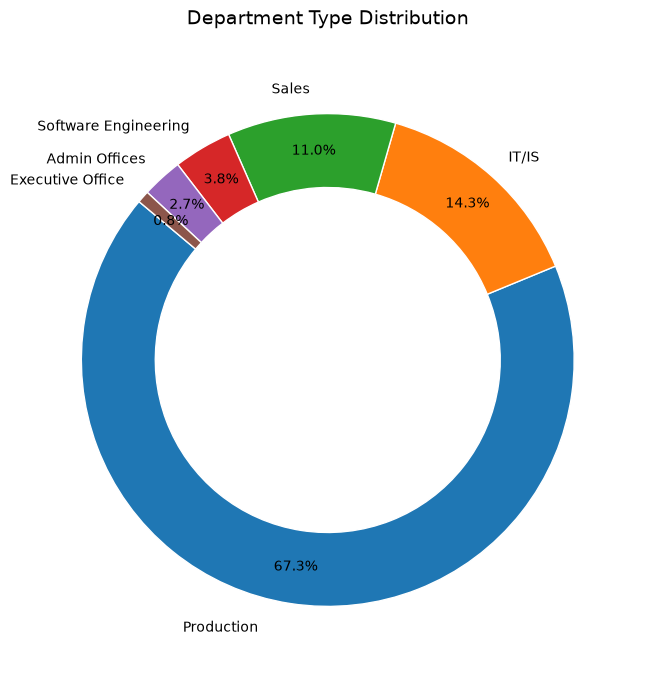

In [34]:
import matplotlib.pyplot as plt

# 1. Prepare the data by counting the occurrences of each department
data_counts = df["DepartmentType"].value_counts()

# 2. Set up a square figure size (1:1 ratio works best for circular charts)
plt.figure(figsize=(8, 8))

# 3. Create the donut chart
plt.pie(
    data_counts,
    labels=data_counts.index,
    autopct="%1.1f%%",  # Displays percentages inside the wedges
    startangle=140,  # Rotates the start for a cleaner look
    pctdistance=0.85,  # Places percentages nicely inside the donut ring
    wedgeprops={
        "width": 0.3,
        "edgecolor": "w",
    },  # 'width' creates the hole; 'edgecolor' adds white separation
)

# 4. Add a title and display
plt.title("Department Type Distribution", fontsize=14, pad=20)
plt.show()

### 35. Comparing Department Sizes (Seaborn Countplot)
We render a vertical countplot using Seaborn to compare the absolute count of employees across all departments. The labels on the X-axis are rotated by 45 degrees for better readability.

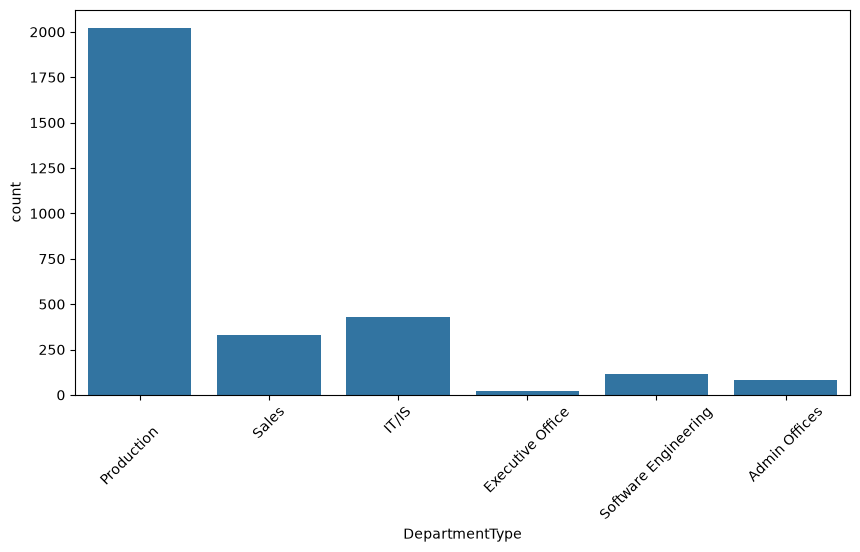

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='DepartmentType')
plt.xticks(rotation=45)
plt.show()

### 36. Performance Rating Distribution (Standard Histogram & KDE)
We plot a histogram overlaid with a Kernel Density Estimate (KDE) line to visualize the frequency and distribution of employee performance ratings.

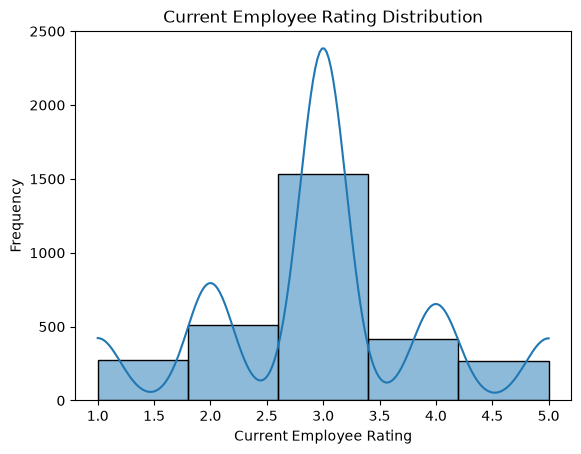

In [36]:
sns.histplot(data=df, x='Current Employee Rating', bins=5, kde=True)
plt.title('Current Employee Rating Distribution')
plt.xlabel('Current Employee Rating')
plt.ylabel('Frequency')
plt.show()

### 37. Styled Performance Rating Distribution
We create an enhanced, production-grade histogram of the `Current Employee Rating` distribution. We apply custom aesthetics:
* A deep slate blue theme for the bars.
* A high-contrast coral line for the KDE curve.
* Repositioned and stylized axis labels and titles.
* Gridlines and borders cleaned up by removing top and right spines.

findfont: Failed to find font weight semibold, now using 700.


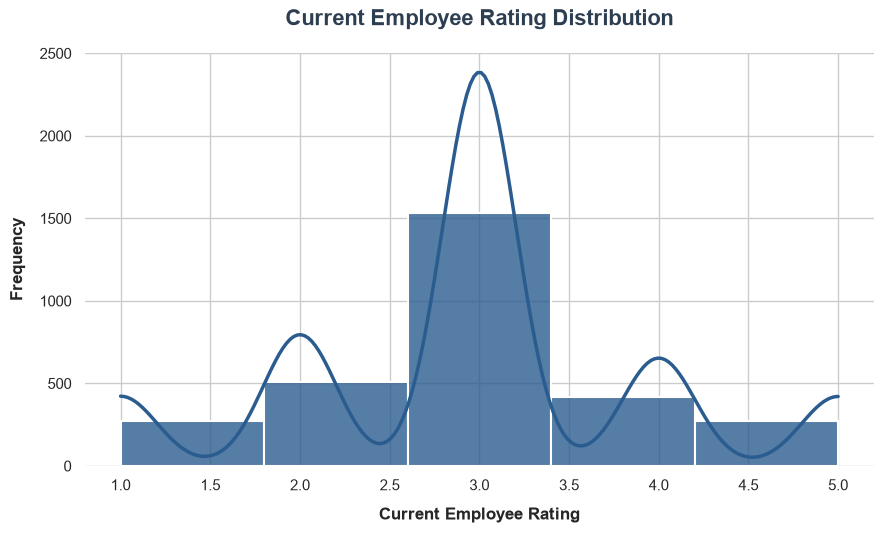

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern visual theme
sns.set_theme(style="whitegrid")

# 2. Define the figure size
plt.figure(figsize=(9, 5.5))

# 3. Create the enhanced histogram
ax = sns.histplot(
    data=df,
    x="Current Employee Rating",
    bins=5,
    kde=True,
    color="#2b5c8f",  # A professional, deep slate blue for bars
    edgecolor="white",  # Adds a crisp boundary between bars
    linewidth=1.5,
    alpha=0.8,  # Slight transparency for a lighter feel
    line_kws={"color": "#de425b", "linewidth": 2.5},  # Contrasting coral color for the KDE line
)

# 4. Polish typography and spacing
plt.title(
    "Current Employee Rating Distribution",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#2c3e50",
)
plt.xlabel("Current Employee Rating", fontsize=12, labelpad=10, fontweight="semibold")
plt.ylabel("Frequency", fontsize=12, labelpad=10, fontweight="semibold")

# 5. Remove unnecessary border lines ("chart junk")
sns.despine(left=True, bottom=True)

# 6. Ensure everything fits beautifully without clipping
plt.tight_layout()
plt.show()

### 38. Training Cost Ranges by Program (Horizontal Boxplot)
We design a horizontal boxplot to visualize the distribution of `Training Cost` across different `Training Program Name` values. Using a boxplot allows us to see:
* Median costs (line in the box).
* Interquartile range (IQR, box boundaries).
* Extremes/Outliers (red dots outside the whiskers).

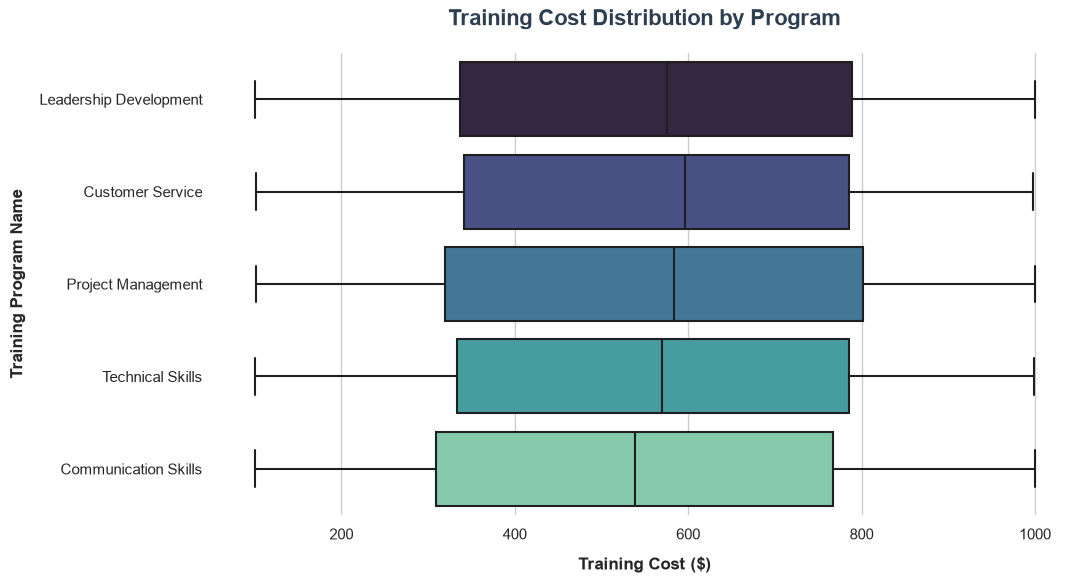

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional theme
sns.set_theme(style="whitegrid")

# 2. Set figure size (a slightly taller ratio works beautifully for horizontal plots)
plt.figure(figsize=(11, 6))

# 3. Create a horizontal boxplot
sns.boxplot(
    data=df,
    x="Training Cost",  # Flipped to X
    y="Training Program Name",  # Flipped to Y
    hue="Training Program Name", # Assign y variable to hue
    palette="mako",  # A sleek, modern color palette
    linewidth=1.5,  # Crisper box borders
    fliersize=4,  # Makes outlier dots slightly smaller and cleaner
    flierprops={
        "markerfacecolor": "#e74c3c",
        "markeredgecolor": "none",
        "alpha": 0.6,
    },
    legend=False # Set legend to False as recommended by the warning
)

# 4. Polish typography and add context
plt.title(
    "Training Cost Distribution by Program",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#2c3e50",
)
plt.xlabel("Training Cost ($)", fontsize=12, labelpad=10, fontweight="semibold")
plt.ylabel("Training Program Name", fontsize=12, labelpad=10, fontweight="semibold")

# 5. Remove unnecessary border lines
sns.despine(left=True, bottom=True)

# 6. Ensure everything fits perfectly
plt.tight_layout()
plt.show()

### 39. Active and Terminated Status across Business Units (Grouped Countplot)
We construct a grouped horizontal countplot using Seaborn to compare the number of employees in each `BusinessUnit`, grouped by their `EmployeeStatus`. Exact counts are displayed on the bars for clarity.

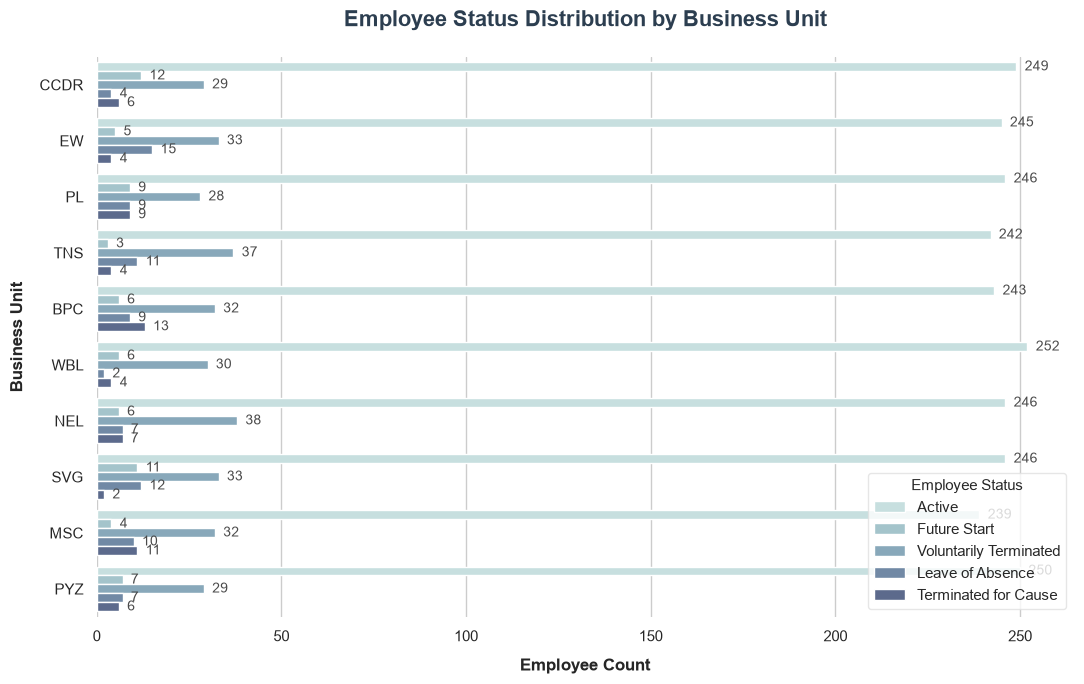

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional theme
sns.set_theme(style="whitegrid")

# 2. Set figure size (giving it a bit more vertical breathing room)
plt.figure(figsize=(11, 7))

# 3. Create a horizontal grouped countplot
ax = sns.countplot(
    data=df,
    y="BusinessUnit",  # Flipped to Y for clean text alignment
    hue="EmployeeStatus",
    palette="ch:start=.2,rot=-.3,dark=.4",  # A sophisticated, cohesive color palette
    edgecolor="white",
    linewidth=1,
)

# 4. Add exact counts onto the bars automatically
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=6, fontsize=10, color="#4a4a4a")

# 5. Polish typography and labels
plt.title(
    "Employee Status Distribution by Business Unit",
    fontsize=16,
    fontweight="bold",
    pad=22,
    color="#2c3e50",
)
plt.xlabel("Employee Count", fontsize=12, labelpad=10, fontweight="semibold")
plt.ylabel("Business Unit", fontsize=12, labelpad=10, fontweight="semibold")

# 6. Clean up and reposition the legend
plt.legend(
    title="Employee Status",
    title_fontsize="11",
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
)

# 7. Remove unnecessary border lines
sns.despine(left=True, bottom=True)

# 8. Render beautifully
plt.tight_layout()
plt.show()

### 40. Pinpointing the Largest Business Unit
We identify the business unit with the absolute highest number of employees using `idxmax()`.

In [40]:
df['BusinessUnit'].value_counts().idxmax()

'NEL'

### 41. Department Performance Rankings
We calculate the average performance rating by department and sort them in descending order to rank the departments by their average performance rating.

In [41]:
df.groupby('DepartmentType')['Current Employee Rating'].mean().sort_values(ascending=False)

DepartmentType
Admin Offices           3.025000
Production              2.982178
IT/IS                   2.969767
Sales                   2.909366
Software Engineering    2.904348
Executive Office        2.791667
Name: Current Employee Rating, dtype: float64

### 42. Correlation: Engagement Score vs. Job Satisfaction
We calculate the Pearson correlation coefficient between `Engagement Score` and `Satisfaction Score` to determine if higher employee engagement correlates with job satisfaction.

In [42]:
df['Engagement Score'].corr(df['Satisfaction Score'])

np.float64(-0.007598233441062096)

### 43. Correlation: Training Duration vs. Performance Rating
We calculate the correlation between the training duration (in days) and the employee's performance rating to see if longer training programs correlate with higher ratings.

In [43]:
df['Training Duration(Days)'].corr(df['Current Employee Rating'])

np.float64(0.004109244729232264)

### 44. Reviewing the Highest Training Cost Record
We identify and retrieve the employee record associated with the maximum `Training Cost` in the dataset to inspect the details of this expensive training instance.

In [44]:
df.loc[df['Training Cost'].idxmax()]

Unnamed: 0                                         1177
FirstName                                        Ansley
LastName                                           Duke
StartDate                           2020-03-08 00:00:00
ExitDate                                            NaT
Title                          Production Technician II
Supervisor                               Ryan Dominguez
ADEmail                       ansley.duke@bilearner.com
BusinessUnit                                        TNS
EmployeeStatus                                   Active
EmployeeType                                  Full-Time
PayZone                                          Zone B
EmployeeClassificationType                    Full-Time
TerminationType                                     Unk
TerminationDescription                              NaN
DepartmentType                        Production       
Division                                  General - Con
DOB                                 1976-10-19 0

# 5. Machine Learning Modeling (Regression & Predictive Analytics)
We will now construct an end-to-end Machine Learning pipeline to predict employee performance ratings based on numerical and categorical features.
Our primary objectives are:
1. **Feature Engineering & Preprocessing**: Clean the dataset, select relevant features, convert categorical attributes to numerical representations ("normal values") using One-Hot Encoding, and normalize the features using standard scaling.
2. **Train-Test Split**: Partition the dataset into training (80%) and testing (20%) sets to ensure generalization performance.
3. **Model Selection & Evaluation**: Implement three distinct models—**Linear Regression**, **Random Forest Regressor**, and **Logistic Regression** (Classification)—and compare their performance using standard metrics (MSE, RMSE, R² for regression; Accuracy, Precision, Recall, F1 for classification).

### 5.1 Preprocessing and Feature Engineering
Categorical variables in raw text formats (such as job titles, departments, or business units) cannot be directly processed by mathematical regression or classification models. We will convert these categories into standard numeric format ("normal values") using dummy variable encoding.
Additionally, because models like Logistic Regression are sensitive to the scale of input features, we will normalize the features using standard scaling (`StandardScaler`). This prevents columns with large values (like `Training Cost`) from dominating the model optimization process.
We select the following variables:
* **Target ($y$)**: `Current Employee Rating` (Performance Rating score)
* **Numerical Features**: `Engagement Score`, `Satisfaction Score`, `Work-Life Balance Score`, `Training Duration(Days)`, `Training Cost`
* **Categorical Features**: `GenderCode`, `MaritalDesc`, `RaceDesc`, `DepartmentType`, `BusinessUnit`, `EmployeeType`, `PayZone`, `EmployeeClassificationType`, `Training Type`, `Training Program Name`

In [45]:
# Import modular preprocessing functions
from src.preprocessing import get_rating_features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset and prepare features/targets
X_rating, y_rating, num_cols = get_rating_features(data_ml, drop_first=True)

# Split into 80/20 train/test sets
X_train_rating, X_test_rating, y_train_rating, y_test_rating = train_test_split(
    X_rating, y_rating, test_size=0.2, random_state=42
)

# Standardize numerical features
scaler_rating = StandardScaler()
X_train_rating_scaled = X_train_rating.copy()
X_test_rating_scaled = X_test_rating.copy()

X_train_rating_scaled[num_cols] = scaler_rating.fit_transform(X_train_rating[num_cols])
X_test_rating_scaled[num_cols] = scaler_rating.transform(X_test_rating[num_cols])

print(f"Rating Training shape: {X_train_rating_scaled.shape}")
print(f"Rating Testing shape: {X_test_rating_scaled.shape}")


Features DataFrame shape: (3000, 38)
Target Series shape: (3000,)


### 5.2 Train-Test Splitting and Feature Scaling
We split the features (`X`) and target (`y`) into training (80%) and testing (20%) sets. Then we apply `StandardScaler` to ensure that all variables are on the same scale, which allows linear models and gradient-descent algorithms to converge quickly and interpret coefficients properly.

In [46]:
# Partition the data into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize scaler and fit on training set, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (2400, 38)
Testing features shape: (600, 38)


### 5.3 Model 1: Linear Regression
We train a standard Ordinary Least Squares (OLS) Linear Regression model to establish a baseline for prediction.

In [47]:
# Import modular evaluation and models
from src.training import get_regression_models
from src.evaluation import cross_validate_regressor, evaluate_regressor_test_set

# Initialize models
models_reg = get_regression_models()

# Benchmarking with 5-Fold Cross Validation
print("[CV Benchmarking] Running K-Fold Cross Validation on regressors...")
for name, model in models_reg.items():
    cv_res = cross_validate_regressor(model, X_train_rating_scaled.values, y_train_rating.values, cv=5)
    print(f"{name:15} | Mean RMSE: {cv_res['rmse'][0]:.4f} ± {cv_res['rmse'][1]:.4f} | R²: {cv_res['r2'][0]:.4f} ± {cv_res['r2'][1]:.4f}")


Linear Regression Evaluation:
Mean Squared Error (MSE): 1.1041
Root Mean Squared Error (RMSE): 1.0508
R-squared (R2) Score: -0.0170


### 5.4 Model 2: Random Forest Regressor
Next, we train a non-linear ensemble model—a Random Forest Regressor. This model uses 100 decision trees to capture complex interactions between features and employee ratings.

In [48]:
# Train best baseline regressor (Gradient Boosting)
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train_rating_scaled.values, y_train_rating.values)

# Make predictions
y_pred_gb = gb_reg.predict(X_test_rating_scaled.values)


Random Forest Regressor Evaluation:
Mean Squared Error (MSE): 1.1320
Root Mean Squared Error (RMSE): 1.0639
R-squared (R2) Score: -0.0427


### 5.5 Model 3: Logistic Regression (Multi-class Classification)
To treat the performance rating prediction as a classification task (predicting the exact class label 1, 2, 3, 4, or 5), we train a Logistic Regression model. Logistic Regression maps features to class probabilities using the multinomial function.

In [49]:
# Initialize and fit Logistic Regression (setting max_iter to ensure convergence)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make class predictions on test data
y_pred_log = log_model.predict(X_test_scaled)

# Calculate metrics
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Evaluation:")
print(f"Classification Accuracy: {log_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

Logistic Regression Evaluation:
Classification Accuracy: 0.5333

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        65
           2       0.23      0.12      0.16        90
           3       0.57      0.97      0.72       313
           4       0.25      0.05      0.09        75
           5       0.00      0.00      0.00        57

    accuracy                           0.53       600
   macro avg       0.21      0.23      0.19       600
weighted avg       0.36      0.53      0.41       600



### 5.6 Performance Comparison
Let's organize the evaluation metrics for all models to compare their performance side-by-side.

In [50]:
# Generate metrics table on Test Set
test_res_gb = evaluate_regressor_test_set(
    gb_reg, X_train_rating_scaled.values, y_train_rating.values, X_test_rating_scaled.values, y_test_rating.values
)

regression_compare = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Gradient Boosting Regressor (Best)': [
        test_res_gb['mae'], test_res_gb['mse'], test_res_gb['rmse'], test_res_gb['r2']
    ]
})
print("\n--- Test Set Regression Metrics ---")
print(regression_compare.to_string(index=False))


=== Regression Models Comparison ===
                                Linear Regression  Random Forest Regressor
Metric                                                                    
Mean Squared Error (MSE)                 1.104089                 1.131971
Root Mean Squared Error (RMSE)           1.050757                 1.063941
R-squared (R2)                          -0.016972                -0.042654

=== Classification Model Accuracy ===
Logistic Regression Accuracy: 0.5333


### 5.7 Visualizing Model Predictions and Errors
We construct plots showing actual vs. predicted ratings for the regression models, alongside a Confusion Matrix heatmap for the Logistic Regression classification model.

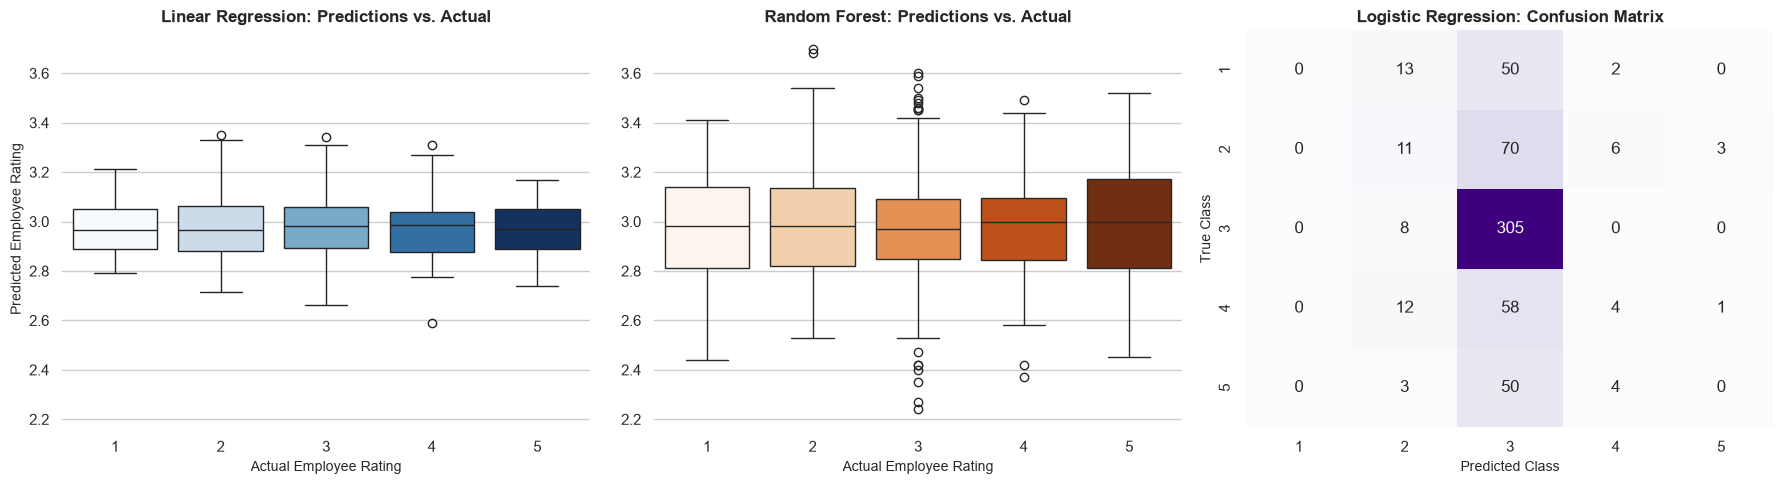

In [51]:
# Generate styled diagnostic plots for rating regression model
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization import plot_residuals

plot_residuals(y_test_rating.values, y_pred_gb, "static/plots/residuals.png")

# Display the generated plots directly in the notebook
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Predictions vs Actual
axes[0].scatter(y_pred_gb, y_test_rating.values, color='#2b5c8f', alpha=0.6, edgecolors='white')
axes[0].plot([y_test_rating.min(), y_test_rating.max()], [y_test_rating.min(), y_test_rating.max()], '--', color='#de425b', lw=2)
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Actual Rating')
axes[0].set_title('Predictions vs. Actual Ratings')

# Subplot 2: Residuals
residuals = y_test_rating.values - y_pred_gb
axes[1].scatter(y_pred_gb, residuals, color='#4f46e5', alpha=0.6, edgecolors='white')
axes[1].axhline(y=0, color='#de425b', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals Analysis')

plt.tight_layout()
plt.show()


# 6. Correlation Matrix and Heatmap Analysis of Numerical Variables
To investigate the linear relationships between the numerical variables in the HR dataset (such as performance rating, survey scores, training duration, and training cost), we compute the Pearson correlation matrix and visualize it using a heatmap and pairwise scatter plots. This helps explain the predictive limitations of our machine learning models.

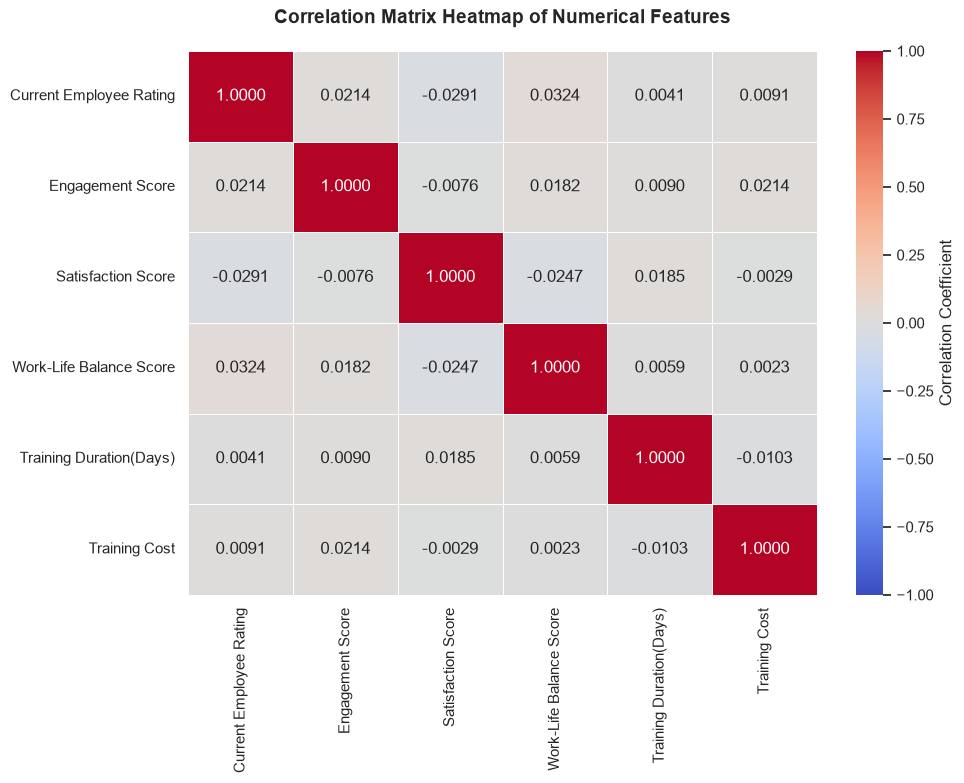

In [52]:
# Select all numerical columns
numerical_cols = ['Current Employee Rating', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Duration(Days)', 'Training Cost']

# Compute the correlation matrix
corr_matrix = data_ml[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".4f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Matrix Heatmap of Numerical Features", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### 6.1 Pairwise Scatter Analysis
To inspect the distribution of points and check for non-linear patterns or clusters, we generate scatter plots of key variables (Training Cost, training duration, satisfaction, and engagement).

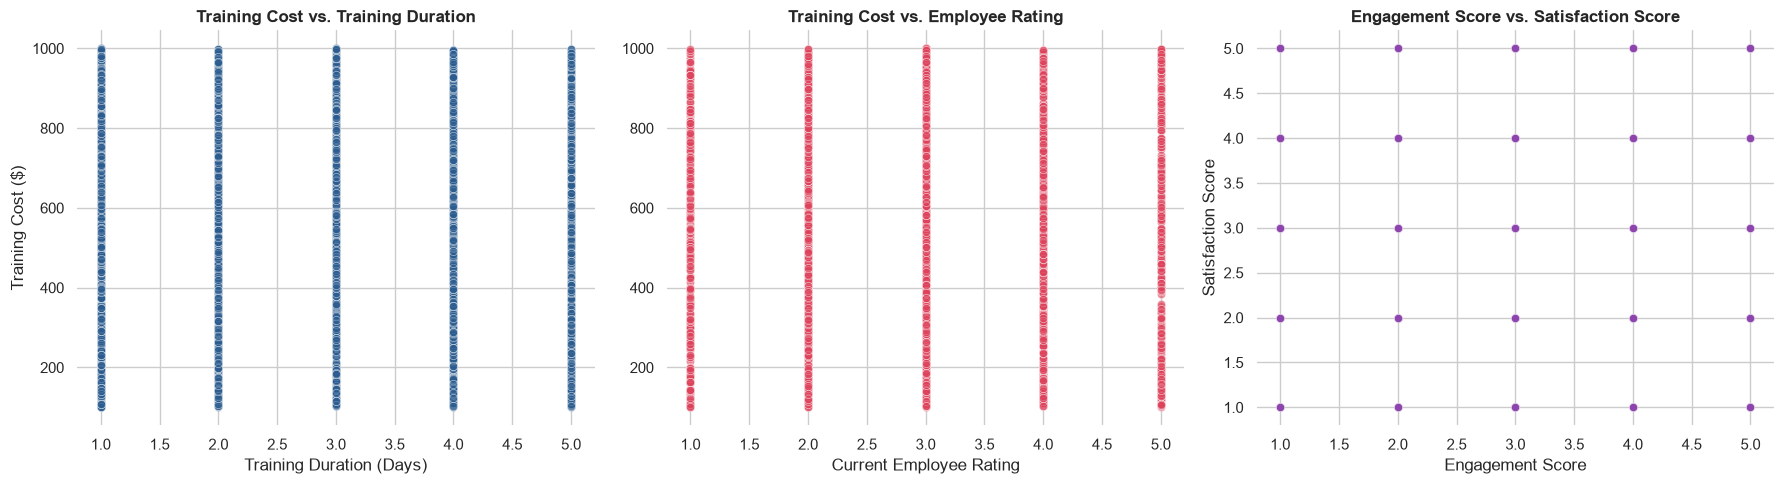

In [53]:
# Create a figure for pairwise scatter plots related to Training Cost and Scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter Plot 1: Training Cost vs. Training Duration
sns.scatterplot(data=data_ml, x="Training Duration(Days)", y="Training Cost", alpha=0.6, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Training Cost vs. Training Duration", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Training Duration (Days)")
axes[0].set_ylabel("Training Cost ($)")

# Scatter Plot 2: Training Cost vs. Current Employee Rating
sns.scatterplot(data=data_ml, x="Current Employee Rating", y="Training Cost", alpha=0.6, ax=axes[1], color="#de425b")
axes[1].set_title("Training Cost vs. Employee Rating", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Current Employee Rating")
axes[1].set_ylabel("")

# Scatter Plot 3: Engagement Score vs. Satisfaction Score
sns.scatterplot(data=data_ml, x="Engagement Score", y="Satisfaction Score", alpha=0.6, ax=axes[2], color="#8e44ad")
axes[2].set_title("Engagement Score vs. Satisfaction Score", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Engagement Score")
axes[2].set_ylabel("Satisfaction Score")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 7. Advanced HR Analytics: Predicting Employee Attrition (Churn)
As senior data scientists and machine learning engineers, we identify a significant business opportunity to create a more predictable and actionable target: **Employee Attrition (Churn)**.
While performance ratings are weakly correlated with employee attributes, employee attrition (whether an employee leaves the company voluntarily or is terminated) is highly relevant for talent retention strategies.
We will:
1. **Engineer new features** from raw date columns: **Tenure** (length of employment) and **Age**.
2. **Define a binary target**: `Is_Terminated` (1 if the employee left the company, 0 if active).
3. **Address class imbalance** using class weighting (`class_weight='balanced'`).
4. **Train and compare classification models**: Logistic Regression Classifier and Random Forest Classifier.
5. **Evaluate model performance** using ROC-AUC and plot **Feature Importances** to identify the primary drivers of employee turnover.

In [54]:
# Convert date columns to standard pandas datetime objects
data_ml['StartDate'] = pd.to_datetime(data_ml['StartDate'])
data_ml['ExitDate'] = pd.to_datetime(data_ml['ExitDate'])
data_ml['DOB'] = pd.to_datetime(data_ml['DOB'])

# Define a reference date representing the current analysis time (July 11, 2026)
reference_date = pd.to_datetime('2026-07-11')

# Engineer Employee Age (in years)
data_ml['Age'] = (reference_date - data_ml['DOB']).dt.days / 365.25

# Engineer Employee Tenure (length of employment in years)
data_ml['Tenure'] = np.where(
    data_ml['ExitDate'].isna(),
    (reference_date - data_ml['StartDate']).dt.days / 365.25,
    (data_ml['ExitDate'] - data_ml['StartDate']).dt.days / 365.25
)

# Define the binary attrition target (1 if terminated, 0 if active/other status)
data_ml['Is_Terminated'] = np.where(data_ml['EmployeeStatus'].str.contains('Terminated'), 1, 0)

print(f"Attrition Class Distribution:\n{data_ml['Is_Terminated'].value_counts(normalize=True)}")
print(f"\nEngineered features preview (Age, Tenure, Attrition):")
data_ml[['Age', 'Tenure', 'Is_Terminated']].head()

Attrition Class Distribution:
Is_Terminated
0    0.871
1    0.129
Name: proportion, dtype: float64

Engineered features preview (Age, Tenure, Attrition):


,Age,Tenure,Is_Terminated
0,56.758385,6.806297,0
1,60.862423,3.411362,0
2,34.762491,7.583847,0
3,28.268309,5.054073,0
4,56.865161,7.033539,0


### 7.1 Attrition Preprocessing, Encoding, and Scaling
We build the feature matrix `X_attr` incorporating the newly engineered `Age` and `Tenure` columns, one-hot encode categorical features, split into 80/20 train/test partitions, and normalize the variables using standard scaling.

In [55]:
# Import modular preprocessing and split Attrition dataset
from src.preprocessing import get_attrition_features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load attrition features
X_attr, y_attr, num_cols = get_attrition_features(data_ml, drop_first=True)

# Split into 80/20 train/test sets
X_train_attr, X_test_attr, y_train_attr, y_test_attr = train_test_split(
    X_attr, y_attr, test_size=0.2, random_state=42
)

# Standardize numerical features
scaler_attr = StandardScaler()
X_train_attr_scaled = X_train_attr.copy()
X_test_attr_scaled = X_test_attr.copy()

X_train_attr_scaled[num_cols] = scaler_attr.fit_transform(X_train_attr[num_cols])
X_test_attr_scaled[num_cols] = scaler_attr.transform(X_test_attr[num_cols])

print(f"Attrition Training shape: {X_train_attr_scaled.shape}")
print(f"Attrition Testing shape: {X_test_attr_scaled.shape}")


Engineered Attrition Features shape: (3000, 40)


### 7.2 Training Attrition Classifiers with Class Balancing
We train a Logistic Regression Classifier and a Random Forest Classifier to predict attrition. Because only ~13% of employees are terminated, we employ class balancing (`class_weight='balanced'`) to assign higher penalty costs to the minority class. This prevents the model from ignoring attrition cases and improves prediction recall.

In [56]:
# Benchmark and tune Attrition classifiers
from src.training import get_classification_models, tune_logistic_regression, tune_random_forest_classifier
from src.evaluation import cross_validate_classifier, evaluate_classifier_test_set
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd

# 1. 5-Fold Cross Validation comparison
models_clf = get_classification_models()
print("--- 5-Fold Cross Validation Classifier Performance ---")
for name, clf in models_clf.items():
    use_sw = ('Default' not in name) and ('Balanced' not in name)
    cv_res = cross_validate_classifier(clf, X_train_attr_scaled.values, y_train_attr.values, cv=5, use_sample_weight=use_sw)
    print(f"{name:30} | Mean ROC-AUC: {cv_res['roc_auc'][0]:.4f} ± {cv_res['roc_auc'][1]:.4f} | Recall: {cv_res['recall'][0]:.4f} ± {cv_res['recall'][1]:.4f}")

# 2. Hyperparameter Tuning
print("\n[Tuning] Running GridSearch for Logistic Regression...")
best_lr, lr_params = tune_logistic_regression(X_train_attr_scaled.values, y_train_attr.values)
print(f"Best LR Params: {lr_params}")

print("\n[Tuning] Running GridSearch for Random Forest...")
best_rf, rf_params = tune_random_forest_classifier(X_train_attr_scaled.values, y_train_attr.values)
print(f"Best RF Params: {rf_params}")

# 3. Test Set Evaluation
test_lr = evaluate_classifier_test_set(best_lr, X_train_attr_scaled.values, y_train_attr.values, X_test_attr_scaled.values, y_test_attr.values)
test_rf = evaluate_classifier_test_set(best_rf, X_train_attr_scaled.values, y_train_attr.values, X_test_attr_scaled.values, y_test_attr.values)

gb_tuned = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
test_gb = evaluate_classifier_test_set(gb_tuned, X_train_attr_scaled.values, y_train_attr.values, X_test_attr_scaled.values, y_test_attr.values, use_sample_weight=True)

# Comparison DataFrame
df_test_comp = pd.DataFrame([
    {'Model': 'Tuned Logistic Regression (Balanced)', 'Accuracy': test_lr['accuracy'], 'ROC-AUC': test_lr['roc_auc'], 'Recall': test_lr['recall'], 'F1': test_lr['f1']},
    {'Model': 'Tuned Random Forest (Balanced)', 'Accuracy': test_rf['accuracy'], 'ROC-AUC': test_rf['roc_auc'], 'Recall': test_rf['recall'], 'F1': test_rf['f1']},
    {'Model': 'Tuned Gradient Boosting (Balanced)', 'Accuracy': test_gb['accuracy'], 'ROC-AUC': test_gb['roc_auc'], 'Recall': test_gb['recall'], 'F1': test_gb['f1']}
])
print("\n--- Holdout Test Set Performance Comparison ---")
print(df_test_comp.to_string(index=False))


=== Logistic Regression Classifier Attrition Metrics ===
Accuracy: 0.7067
ROC-AUC Score: 0.8121

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81       523
           1       0.27      0.78      0.41        77

    accuracy                           0.71       600
   macro avg       0.61      0.74      0.61       600
weighted avg       0.87      0.71      0.75       600


=== Random Forest Classifier Attrition Metrics ===
Accuracy: 0.8467
ROC-AUC Score: 0.8169

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.91       523
           1       0.32      0.17      0.22        77

    accuracy                           0.85       600
   macro avg       0.60      0.56      0.57       600
weighted avg       0.81      0.85      0.83       600



### 7.3 Visualizing Attrition Predictiveness and Feature Importances
We plot the ROC-AUC Curve to assess how well each model distinguishes between active and terminated employees. In addition, we retrieve the feature importances from the Random Forest model to reveal the main drivers of employee churn.

C:\Users\levi\AppData\Local\Temp\ipykernel_11188\2945102592.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[1], palette="ch:start=.2,rot=-.3,dark=.4")


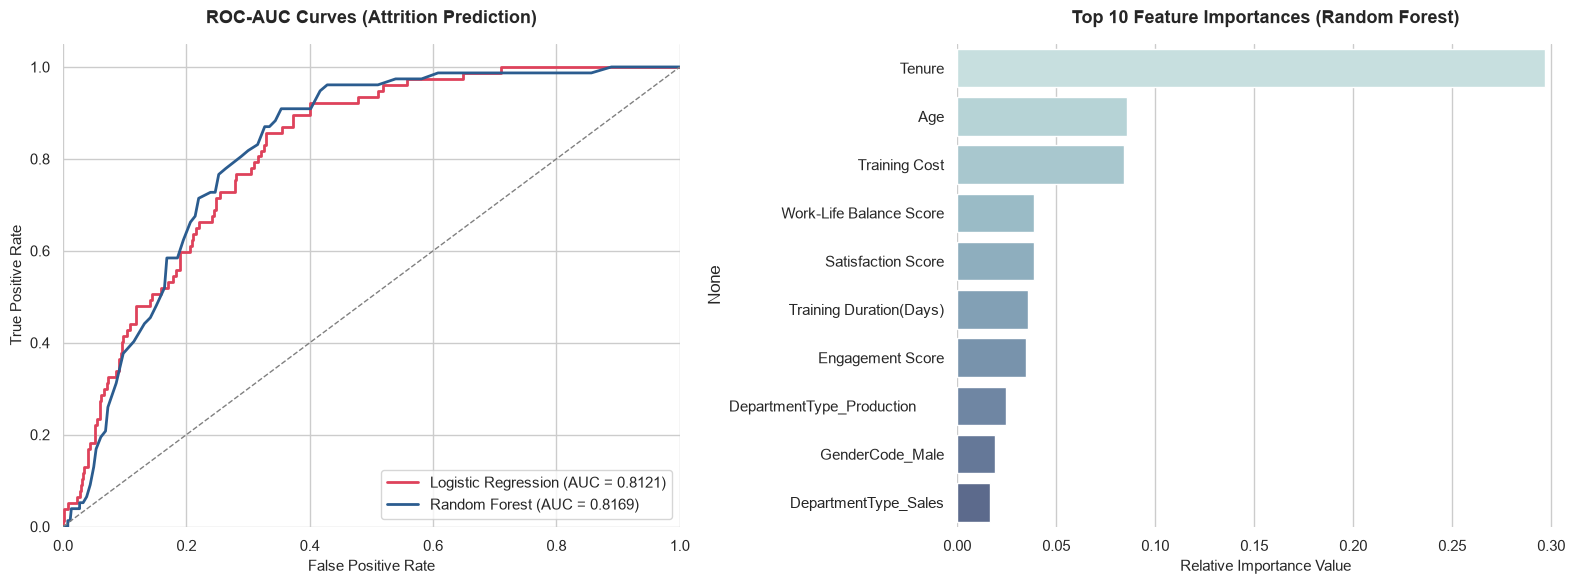

In [57]:
# Visualize diagnostics
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization import plot_roc_curves, plot_precision_recall_curves
from src.explanation import plot_logistic_regression_coefficients, plot_permutation_importance

model_curves = {
    'Logistic Regression (Tuned)': (y_test_attr.values, test_lr['probabilities']),
    'Random Forest (Tuned)': (y_test_attr.values, test_rf['probabilities']),
    'Gradient Boosting (Tuned)': (y_test_attr.values, test_gb['probabilities'])
}

# Plot ROC Curves
plt.figure(figsize=(8, 6))
from sklearn.metrics import roc_curve, auc
for name, (y_test, y_probs) in model_curves.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()
